# TIFF-Übersicht für test_output_ulm
Dieses Notebook lädt und visualisiert alle TIFF-Dateien im Ordner `/tmp/test_output_ulm`.

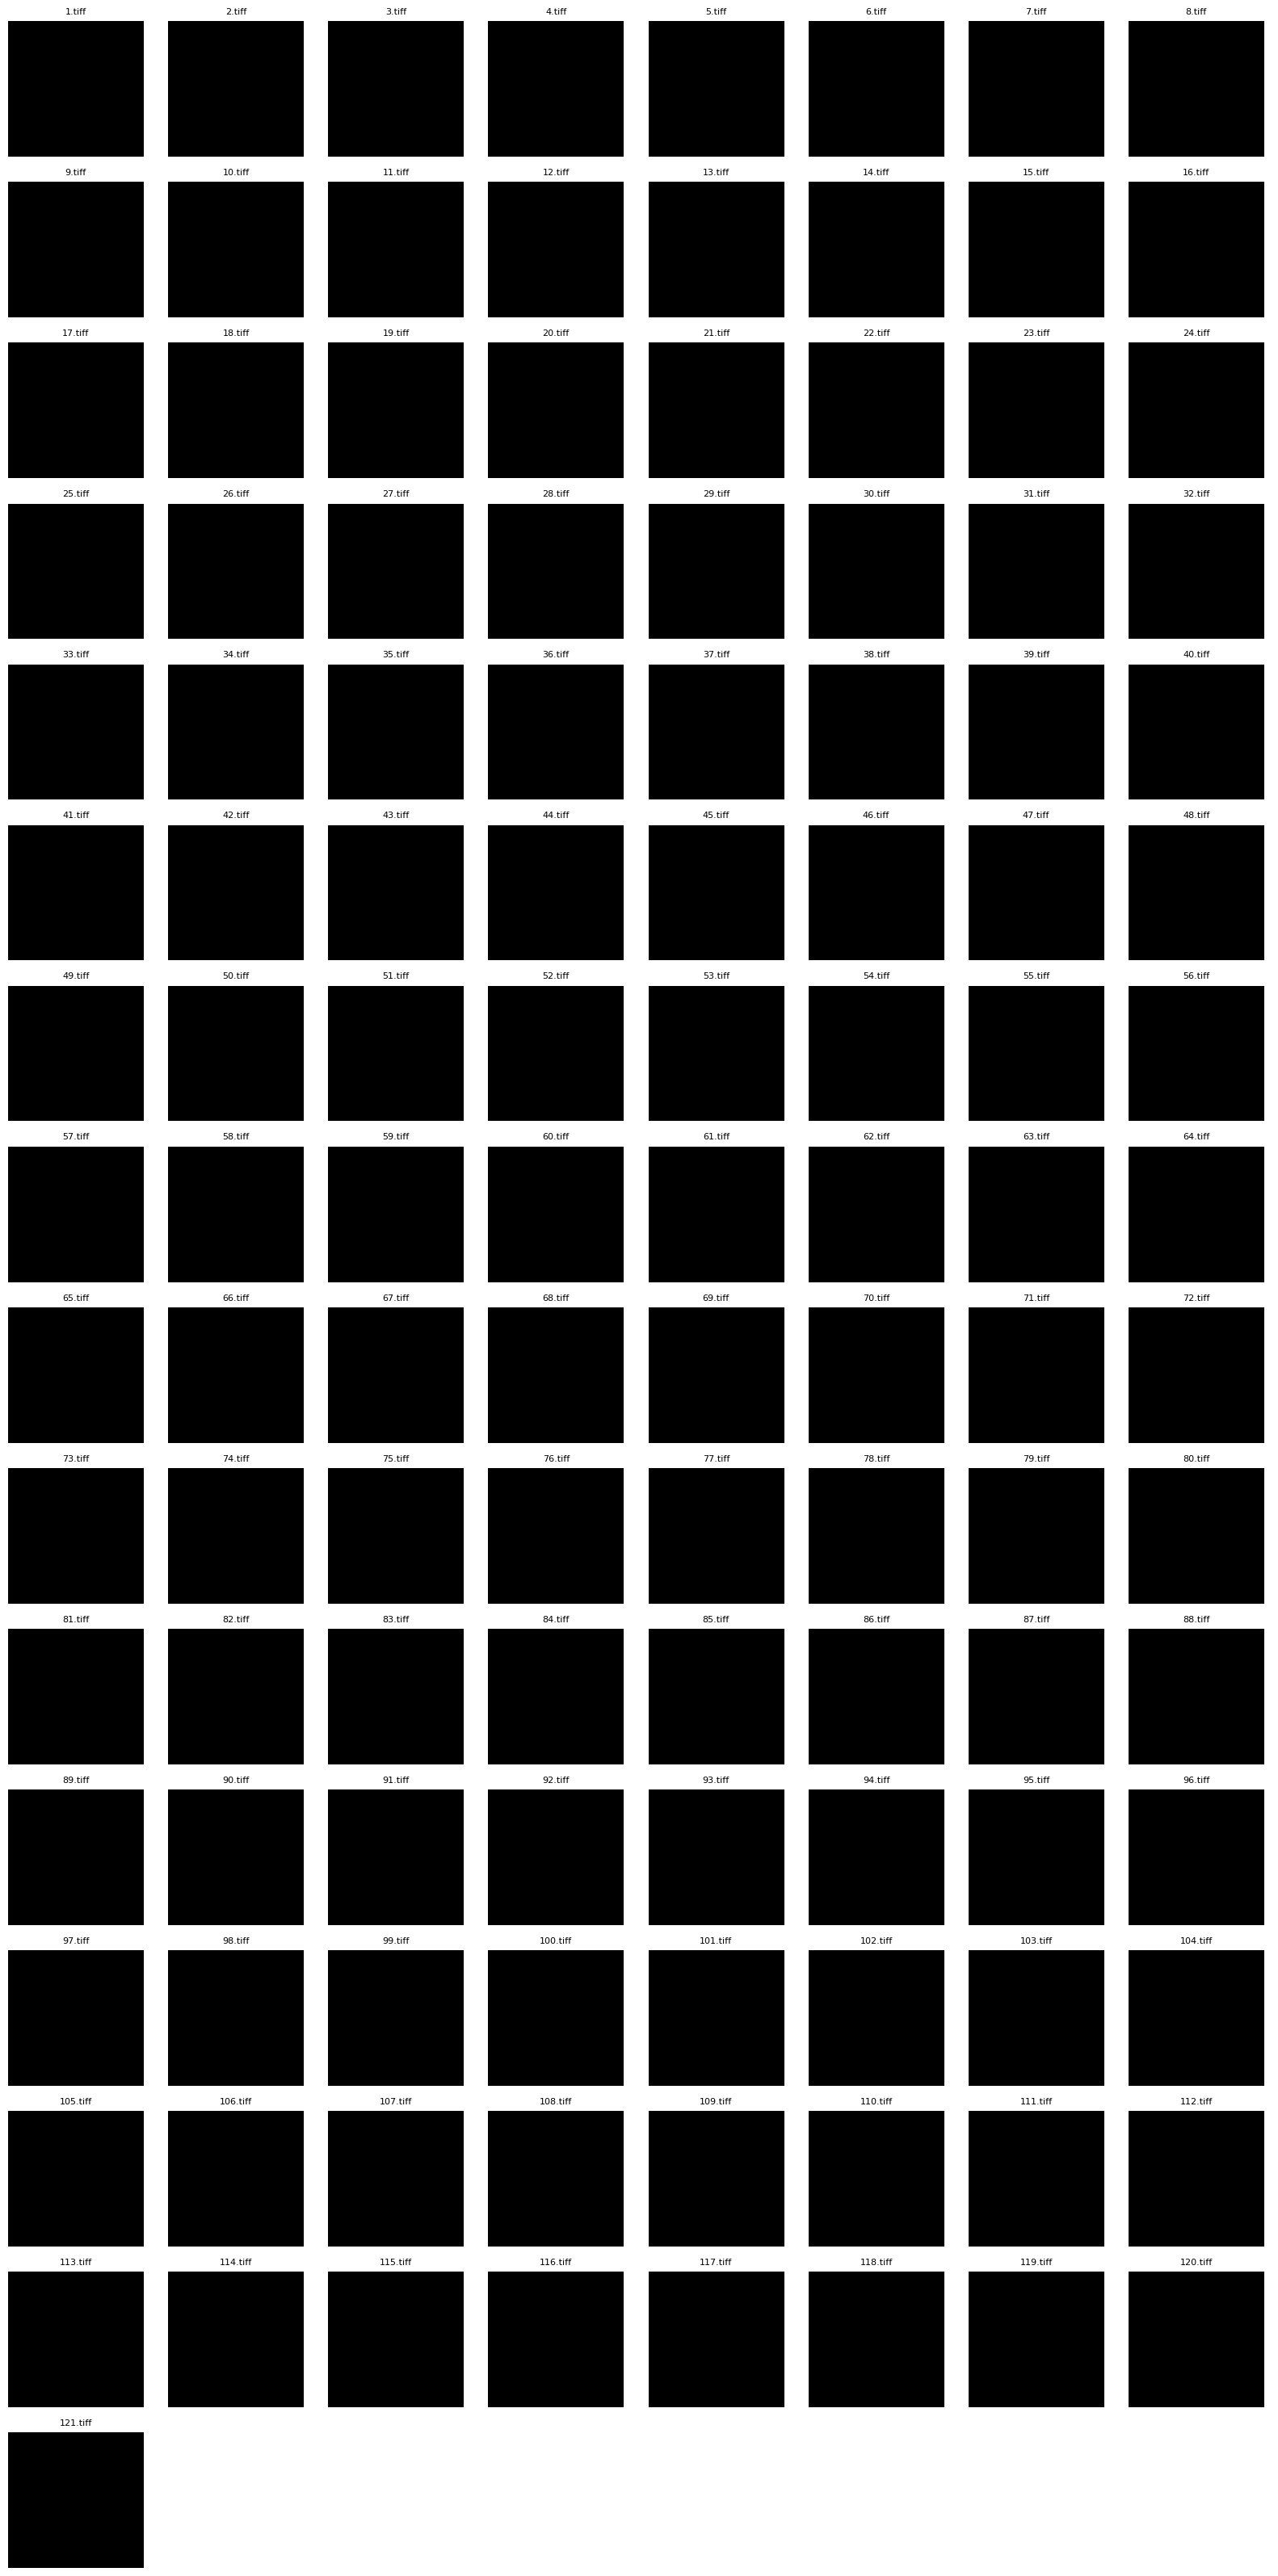

In [1]:
import os
import matplotlib.pyplot as plt
import rasterio

folder = '/tmp/test_output_ulm'
files = [f for f in os.listdir(folder) if f.endswith('.tiff') or f.endswith('.tif')]
files.sort(key=lambda x: int(x.split('.')[0]))  # Sortiere numerisch

n = len(files)
cols = 8
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
axes = axes.flatten()

for ax, fname in zip(axes, files):
    path = os.path.join(folder, fname)
    with rasterio.open(path) as src:
        img = src.read(1)
    ax.imshow(img, cmap='gray')
    ax.set_title(fname, fontsize=8)
    ax.axis('off')

# Leere Achsen ausblenden
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()